--- Iniciando Entrenamiento (Dueling DQN - Sin Clase) ---
Episodio: 50/1000, Pasos: 36, Recompensa Promedio (50 ep): 21.76, Epsilon: 0.837
Episodio: 100/1000, Pasos: 25, Recompensa Promedio (50 ep): 39.24, Epsilon: 0.670
Episodio: 150/1000, Pasos: 163, Recompensa Promedio (50 ep): 67.22, Epsilon: 0.504
Episodio: 200/1000, Pasos: 207, Recompensa Promedio (50 ep): 88.72, Epsilon: 0.337
Episodio: 250/1000, Pasos: 201, Recompensa Promedio (50 ep): 119.48, Epsilon: 0.171
Episodio: 300/1000, Pasos: 500, Recompensa Promedio (50 ep): 268.26, Epsilon: 0.004
Episodio: 350/1000, Pasos: 475, Recompensa Promedio (50 ep): 422.48, Epsilon: 0.001
Episodio: 400/1000, Pasos: 304, Recompensa Promedio (50 ep): 391.62, Epsilon: 0.001
Episodio: 450/1000, Pasos: 500, Recompensa Promedio (50 ep): 395.52, Epsilon: 0.001
Episodio: 500/1000, Pasos: 500, Recompensa Promedio (50 ep): 458.54, Epsilon: 0.001
Episodio: 550/1000, Pasos: 500, Recompensa Promedio (50 ep): 298.02, Epsilon: 0.001
Episodio: 600/1000, Pasos

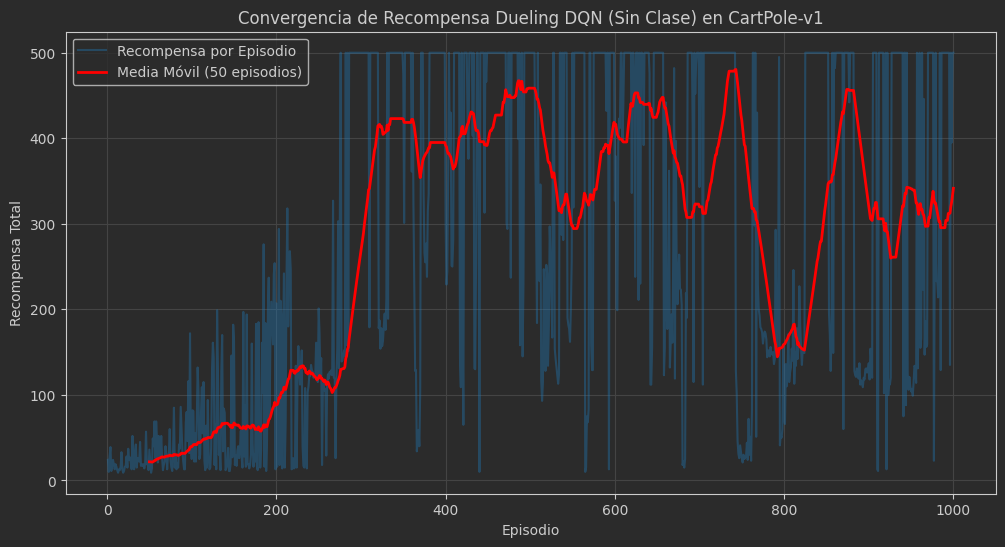


--- Jugando con la política aprendida (Evaluación) ---
Evaluación 1, Recompensa: 392.0, Pasos: 392
Evaluación 2, Recompensa: 363.0, Pasos: 363
Evaluación 3, Recompensa: 364.0, Pasos: 364
Evaluación 4, Recompensa: 365.0, Pasos: 365
Evaluación 5, Recompensa: 374.0, Pasos: 374
Evaluación 6, Recompensa: 378.0, Pasos: 378
Evaluación 7, Recompensa: 368.0, Pasos: 368
Evaluación 8, Recompensa: 393.0, Pasos: 393
Evaluación 9, Recompensa: 413.0, Pasos: 413
Evaluación 10, Recompensa: 379.0, Pasos: 379

Recompensa Promedio en Evaluación (10 episodios): 378.90


In [ ]:
# -*- coding: utf-8 -*-
"""

Automatically generated by Colab.

"""

import torch
import torch.nn as nn
import torch.optim as optim
import gymnasium as gym
import random
import numpy as np
import collections # Para el Replay Buffer (deque)
import matplotlib.pyplot as plt # Para graficar
from itertools import chain # Para combinar parámetros para el optimizador

plt.rcParams.update({
    'figure.facecolor': '#2b2b2b',     # fondo exterior
    'axes.facecolor':   '#2b2b2b',     # fondo del área del gráfico
    'axes.edgecolor':   '#cccccc',     # borde de los ejes
    'axes.labelcolor':  '#cccccc',     # etiquetas de los ejes
    'xtick.color':      '#cccccc',     # color de los números en el eje X
    'ytick.color':      '#cccccc',     # color de los números en el eje Y
    'text.color':       '#cccccc',     # color del título y textos
    'grid.color':       '#444444',     # color de la grilla
})

# --- Hiperparámetros (Mantenidos iguales) ---
max_episodes = 1000
max_steps_per_episode = 500
learning_rate = 0.001
gamma = 0.99
epsilon_start = 1.0
epsilon_end = 0.001
epsilon_decay_episodes = 300
buffer_size = 10_000
batch_size = 64
target_update_freq = 100
print_every = 50
smoothing_window = 50

# --- Entorno ---
env = gym.make('CartPole-v1')
n_observations = env.observation_space.shape[0]
n_actions = env.action_space.n

# --- Red Neuronal (Dueling Q-Network - ---
# *** Definición de las partes de la red ***

# 1. Capas compartidas
def create_feature_layer():
    return nn.Sequential(
        nn.Linear(n_observations, 128),
        nn.ReLU()
        # Mantenemos una estructura simple similar al original
    )

# 2. Stream de Valor (V(s))
def create_value_stream():
    return nn.Sequential(
        nn.Linear(128, 128), # Capa oculta para el valor
        nn.ReLU(),
        nn.Linear(128, 1)    # Salida única para V(s)
    )

# 3. Stream de Ventaja (A(s,a))
def create_advantage_stream():
    return nn.Sequential(
        nn.Linear(128, 128), # Capa oculta para la ventaja
        nn.ReLU(),
        nn.Linear(128, n_actions) # Salida por cada acción para A(s,a)
    )

# --- Instanciación de las redes Online y Target ---
# Red Online
feature_layer_online = create_feature_layer()
value_stream_online = create_value_stream()
advantage_stream_online = create_advantage_stream()

# Red Target
feature_layer_target = create_feature_layer()
value_stream_target = create_value_stream()
advantage_stream_target = create_advantage_stream()

# Copia pesos iniciales a la red objetivo y pasarla a modo evaluación
def initialize_target_networks():
    feature_layer_target.load_state_dict(feature_layer_online.state_dict())
    value_stream_target.load_state_dict(value_stream_online.state_dict())
    advantage_stream_target.load_state_dict(advantage_stream_online.state_dict())
    feature_layer_target.eval()
    value_stream_target.eval()
    advantage_stream_target.eval()

initialize_target_networks()

# --- Optimizador ---
# *** parámetros de todas las partes de la red  ***
all_online_params = chain(
    feature_layer_online.parameters(),
    value_stream_online.parameters(),
    advantage_stream_online.parameters()
)
optimizer = optim.Adam(all_online_params, lr=learning_rate)
loss_fn = nn.MSELoss()

# --- Función para calcular Q-valores (Dueling) ---
# *** Función explícita para combinar las partes ***
def get_q_values(state, feature_layer, value_stream, advantage_stream):
    features = feature_layer(state)
    values = value_stream(features)
    advantages = advantage_stream(features)
    # Q(s,a) = V(s) + (A(s,a) - mean(A(s,a')))
    q_values = values + (advantages - advantages.mean(dim=-1, keepdim=True)) # Usar dim=-1 por si el batch size es 1
    return q_values

# --- Replay Buffer ---
Transition = collections.namedtuple('Transition',
                                    ('state', 'action', 'reward', 'next_state', 'done'))
replay_buffer = collections.deque(maxlen=buffer_size)

# --- Función para actualizar la Red ---
def update_target_network():
    feature_layer_target.load_state_dict(feature_layer_online.state_dict())
    value_stream_target.load_state_dict(value_stream_online.state_dict())
    advantage_stream_target.load_state_dict(advantage_stream_online.state_dict())

# --- Entrenamiento ---
global_step = 0
epsilon = epsilon_start
episode_rewards_history = []

print("--- Iniciando Entrenamiento (Dueling DQN - ---")
for episode in range(max_episodes):
    obs, info = env.reset()
    state = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
    episode_reward = 0
    episode_steps = 0

    for step in range(max_steps_per_episode):
        global_step += 1
        episode_steps += 1

        # --- Selección de Acción (Epsilon-Greedy) ---
        if random.random() < epsilon:
            action = torch.tensor([[env.action_space.sample()]], dtype=torch.long)
        else:
            with torch.no_grad():
                # ***  Llama a la función get_q_values ***
                q_values = get_q_values(state, feature_layer_online, value_stream_online, advantage_stream_online)
                action = q_values.max(1)[1].view(1, 1)

        # --- Ejecutar acción en el entorno ---
        next_obs, reward, terminated, truncated, info = env.step(action.item())
        done = terminated or truncated
        episode_reward += reward

        reward_tensor = torch.tensor([reward], dtype=torch.float32)
        if terminated:
            next_state = None
        else:
            next_state = torch.tensor(next_obs, dtype=torch.float32).unsqueeze(0)
        done_tensor = torch.tensor([done], dtype=torch.float32)

        # --- Guardar transición en el Replay Buffer ---
        replay_buffer.append(Transition(state, action, reward_tensor, next_state, done_tensor))

        state = next_state

        # --- Aprendizaje desde el Replay Buffer ---
        if len(replay_buffer) >= batch_size:
            transitions = random.sample(replay_buffer, batch_size)
            batch = Transition(*zip(*transitions))

            non_final_mask = torch.tensor(tuple(map(lambda s: s is not None, batch.next_state)), dtype=torch.bool)
            non_final_next_states = torch.cat([s for s in batch.next_state if s is not None])

            state_batch = torch.cat(batch.state)
            action_batch = torch.cat(batch.action)
            reward_batch = torch.cat(batch.reward)

            # *** Calc. Q(s,a) usando la función get_q_values con la red  ***
            q_online_all = get_q_values(state_batch, feature_layer_online, value_stream_online, advantage_stream_online)
            state_action_values = q_online_all.gather(1, action_batch).squeeze(1)


            next_state_values = torch.zeros(batch_size)
            if non_final_next_states.nelement() > 0: # Asegurarse de que hay estados siguientes no finales
                with torch.no_grad():
                    # ***  Calcular max Q(s',a') usando la función get_q_values con la red target ***
                    q_target_next_all = get_q_values(non_final_next_states, feature_layer_target, value_stream_target, advantage_stream_target)
                    next_state_values[non_final_mask] = q_target_next_all.max(1)[0]

            # Calcula el valor Q esperado (target)
            expected_state_action_values = reward_batch + (gamma * next_state_values)

            # Calcula la pérdida
            loss = loss_fn(state_action_values, expected_state_action_values)

            # Optimización
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # --- Actualiz. la Red Objetivo ---
        # ***  Llama a la función actualizada ***
        if global_step % target_update_freq == 0:
            update_target_network()

        if done:
            break

    # --- Guarda recompensa y decaimiento de Epsilon ---
    episode_rewards_history.append(episode_reward)
    epsilon = max(epsilon_end, epsilon_start - (episode / epsilon_decay_episodes) * (epsilon_start - epsilon_end))

    if (episode + 1) % print_every == 0:
        avg_reward = np.mean(episode_rewards_history[-print_every:])
        print(f'Episodio: {episode + 1}/{max_episodes}, Pasos: {episode_steps}, Recompensa Promedio ({print_every} ep): {avg_reward:.2f}, Epsilon: {epsilon:.3f}')

print("--- Entrenamiento Finalizado ---")

# --- Grafic. Curva de Convergencia ---
print("\n--- Generando Gráfico de Convergencia ---")
plt.figure(figsize=(12, 6))
plt.plot(range(1, max_episodes + 1), episode_rewards_history, label='Recompensa por Episodio', alpha=0.4)
if len(episode_rewards_history) >= smoothing_window:
    rewards_smoothed = np.convolve(episode_rewards_history, np.ones(smoothing_window)/smoothing_window, mode='valid')
    plt.plot(range(smoothing_window, max_episodes + 1), rewards_smoothed, label=f'Media Móvil ({smoothing_window} episodios)', color='red', linewidth=2)
plt.xlabel("Episodio")
plt.ylabel("Recompensa Total")
plt.title("Convergencia de Recompensa Dueling DQN (Sin Clase) en CartPole-v1") # <-- Título actualizado
plt.legend()
plt.grid(True)
plt.show()


# --- (Evaluación SIN RENDERIZADO) ---
print("\n--- prueba de la política aprendida (Evaluación) ---")
eval_env = gym.make('CartPole-v1')
total_eval_reward = 0
num_eval_episodes = 10

for i in range(num_eval_episodes):
    obs, info = eval_env.reset()
    state = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
    done = False
    episode_eval_reward = 0
    episode_steps = 0
    while not done and episode_steps < max_steps_per_episode:
        with torch.no_grad():
            # ***  Usa get_q_values con la red entrenada ***
            q_values = get_q_values(state, feature_layer_online, value_stream_online, advantage_stream_online)
            action = q_values.max(1)[1].view(1, 1)

        obs, reward, terminated, truncated, info = eval_env.step(action.item())
        done = terminated or truncated
        episode_eval_reward += reward
        episode_steps += 1
        if not done:
            state = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)

    print(f'Evaluación {i+1}, Recompensa: {episode_eval_reward}, Pasos: {episode_steps}')
    total_eval_reward += episode_eval_reward

print(f'\nRecompensa Promedio en Evaluación ({num_eval_episodes} episodios): {total_eval_reward / num_eval_episodes:.2f}')
eval_env.close()
env.close()